# ATN DAC Trajectory Data Quality Control Example

This notebook demonstrates how to apply quality control (QC) tests to Animal Telemetry Network (ATN) satellite telemetry data using the [`ioos_qc`](https://github.com/ioos/ioos_qc) Python package (see [docs](https://ioos.github.io/ioos_qc/)).

The ATN DAC applies automated QC to all ingested trajectory and profile data, most of which are currently coming from Wildlife Computers and SMRU instruments. This notebook shows the exact tests and thresholds used in our operational pipeline, allowing users to:

1. Understand what QC is being applied to ATN data
2. Replicate the QC process on their own data
3. Interpret the QC flags embedded in ATN data products

**Here is a summary of the tests applied to ATN trajectory data.**

| Test | Module | Thresholds | Purpose |
|------|--------|------------|---------|
| `location_test` | `ioos_qc.qartod` | bbox: [-180, -90, 180, 90] | Valid geographic bounds |
| `speed_test` | `ioos_qc.argo` | suspect: 8 m/s, fail: 10 m/s | Realistic movement speeds |
| `valid_range_test` | `ioos_qc.axds` | deployment dates | Deployment period bounds |


**Below are the QC flags and their meaning.**

| Flag | Meaning |
|------|---------|
| 1 | PASS - Data passed all QC tests |
| 2 | NOT_EVALUATED - Test not performed |
| 3 | SUSPECT - Data questionable, use with caution |
| 4 | FAIL - Data failed QC, should not be used |
| 9 | MISSING - Data is missing |

Please see the [ATN Satellite Telemetry Specifications, Quality Control Protocols section](https://ioos.github.io/ioos-atn-data/atn-sat-telem-specification-v1-0.html#quality-control-protocols) for the most up to date information on tests applied and configured thresholds in the ATN DAC.

In [1]:

# QC libraries
from ioos_qc.config import Config
from ioos_qc.streams import PandasStream
from ioos_qc.stores import PandasStore
from ioos_qc.utils import great_circle_distance

# Core data handling
from datetime import datetime
import pandas as pd
import numpy as np
import io
import zipfile
import requests
import xarray as xr

# Visualization
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## QC Trajectory Data

Below, we demonstrate QC using an [example dataset](https://portal.atn.ioos.us/#metadata/af7f5c48-2772-4960-a70f-c44f49f30cc0/project/0ce1485b-f8bd-56a5-a1fc-a8369e7990cd/platform?d=foiegras) from a Harbor Seal tag (PTT ID: 41820, Animal ID: PV2004_0217) deployed in Alaska. Data are from Wildlife Computer, which we process and QC, show on the portal, and submit to NCEI for archival. We will compare our QCed version of the raw data that is accessible on the [ATN Portal](https://portal.atn.ioos.us/#metadata/af7f5c48-2772-4960-a70f-c44f49f30cc0/project/files) with that available at NCEI.

In [ ]:
# Data for example deployment (PTT ID: 41820, Animal ID: PV2004_0217, Deployment ID: PV2004_0217_03T0073) is at the following URL:
deployment_url = "https://researchworkspace.com/published/file/18275205-dece-426f-a2e7-ba444b6dc925/PV2004_0217_03T0073.zip?source=catalog&portalId=99"

response = requests.get(deployment_url)
response.raise_for_status()

# Extract the ZIP file contents
zip_buffer = io.BytesIO(response.content)
zf = zipfile.ZipFile(zip_buffer)

# List files in the ZIP
print(f"\nFiles in deployment ZIP:")
for filename in sorted(zf.namelist()):
    print(f"  - {filename}")


Files in deployment ZIP:
  - 41820-All.csv
  - 41820-Argos.csv
  - 41820-Corrupt.csv
  - 41820-Histos.csv
  - 41820-Labels.csv
  - 41820-Locations.csv
  - 41820-RTC.csv
  - 41820-RawArgos.csv
  - 41820-Status.csv
  - 41820-Summary.csv
  - 41820.kmz
  - 41820.prv
  - 41820.pxp
  - sources.txt


### 0. Prepare Data

In [3]:
# Load the Argos position data in the Locations file for trajectory QC
argos_file = "41820-Locations.csv"

with zf.open(argos_file) as f:
    trajectory_df = pd.read_csv(f)

In [4]:
# Show first few records
print("\nFirst 5 records:")
trajectory_df.head()


First 5 records:


,DeployID,Ptt,Instr,Date,Type,Quality,Latitude,Longitude,Error radius,Error Semi-major axis,Error Semi-minor axis,Error Ellipse orientation,Offset,Offset orientation,GPE MSD,GPE U,Count,Comment
0,PV2004_0217_03T0073,41820,ST16,00:37:09 31-Aug-2004,Argos,A,59.741,-153.354,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PV2004_0217_03T0073,41820,ST16,02:06:43 31-Aug-2004,Argos,B,59.763,-153.395,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PV2004_0217_03T0073,41820,ST16,03:03:58 31-Aug-2004,Argos,0,59.739,-153.430,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PV2004_0217_03T0073,41820,ST16,04:47:07 31-Aug-2004,Argos,A,59.735,-153.426,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PV2004_0217_03T0073,41820,ST16,05:24:48 31-Aug-2004,Argos,B,59.669,-153.590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Prepare data for QC
# Standardize column names and convert datetime

# Find the relevant columns
lat_col, lon_col, date_col = "Latitude", "Longitude", "Date"

# Parse datetime
trajectory_df[date_col] = pd.to_datetime(trajectory_df[date_col])
trajectory_df = trajectory_df.sort_values(date_col).reset_index(drop=True)

# Convert to Unix timestamp (seconds) for speed calculations.
# Explicitly cast through datetime64[s] so this is correct regardless of
# whether pandas stores datetimes as ns or us resolution (pandas 2.x changed default).
trajectory_df['timestamp'] = trajectory_df[date_col].values.astype('datetime64[s]').astype('int64')

# Set start and end deployment dates supplied by PI to the ATN Data Registration App (to exactly match the processed file)
deploy_start, deploy_end = pd.to_datetime("2004-08-30 20:40:00"), pd.to_datetime("2004-12-29 07:00:00")
deploy_start = datetime.combine(deploy_start, datetime.min.time())
deploy_end = datetime.combine(deploy_end, datetime.max.time())


### 1. Explore the Trajectory Data

Let's examine the data to understand what we're working with before applying QC.

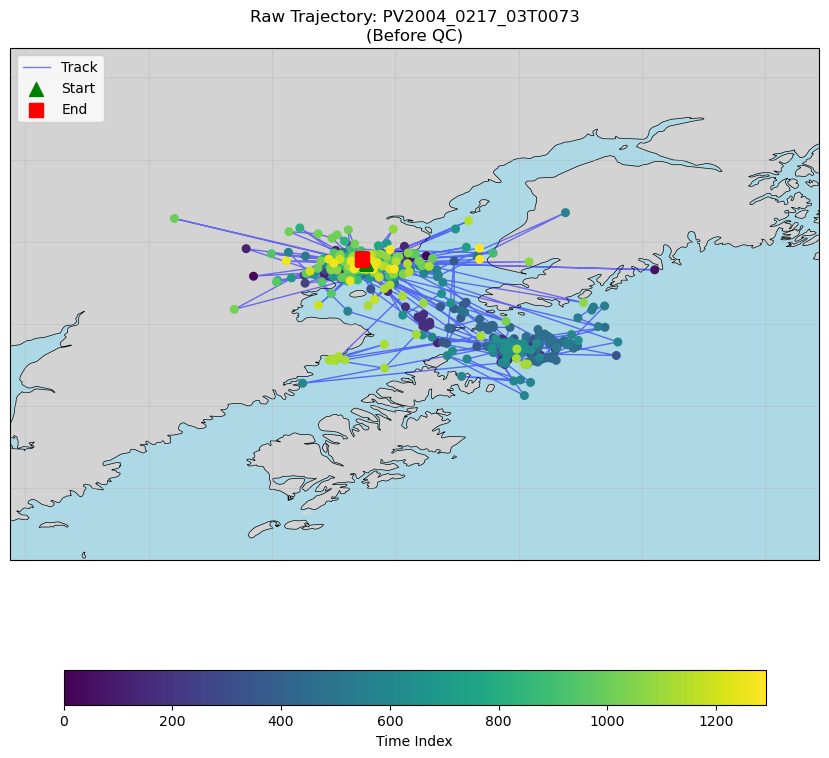


Total points: 1292, Valid coordinates: 1292


In [6]:
# Visualize the raw track before QC
fig, ax = plt.subplots(1, 1, figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Filter valid coordinates for extent calculation
valid_mask = (trajectory_df[lat_col].between(-90, 90)) & (trajectory_df[lon_col].between(-180, 180))
valid_data = trajectory_df[valid_mask]

# Set map extent with some padding
lon_min, lon_max = valid_data[lon_col].min() - 2, valid_data[lon_col].max() + 2
lat_min, lat_max = valid_data[lat_col].min() - 2, valid_data[lat_col].max() + 2

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
# add gridlines
ax.gridlines(linewidth=0.5, alpha=0.5)

# Plot trajectory
ax.plot(valid_data[lon_col], valid_data[lat_col],
        'b-', linewidth=1, alpha=0.5, transform=ccrs.PlateCarree(), label='Track')
map = ax.scatter(valid_data[lon_col], valid_data[lat_col], 
           c=range(len(valid_data)), cmap='viridis', s=30, 
           transform=ccrs.PlateCarree(), zorder=5)
plt.colorbar(map, ax=ax, orientation='horizontal', label='Time Index', shrink=0.6)

# Mark start and end
ax.scatter(valid_data[lon_col].iloc[0], valid_data[lat_col].iloc[0],
           c='green', s=100, marker='^', transform=ccrs.PlateCarree(), 
           zorder=10, label='Start')
ax.scatter(valid_data[lon_col].iloc[-1], valid_data[lat_col].iloc[-1],
           c='red', s=100, marker='s', transform=ccrs.PlateCarree(), 
           zorder=10, label='End')

# Get deployment ID if available
deploy_id = trajectory_df['DeployID'].iloc[0] if 'DeployID' in trajectory_df.columns else 'Unknown'

ax.legend(loc='upper left')
ax.set_title(f"Raw Trajectory: {deploy_id}\n(Before QC)")
plt.tight_layout()
plt.show()

print(f"\nTotal points: {len(trajectory_df)}, Valid coordinates: {len(valid_data)}")


### 2. Configure QC Tests

Now we'll configure the QC tests using `ioos_qc`. The ATN DAC applies the Location Test and Speed Test to trajectory data to ensure positions fall within valid geographic bounds and checks for biologically implausable movement speeds. It also tests for being in the valid time range.

In [8]:
# QC Test Thresholds used by ATN DAC
# These are defined based on biological plausibility for marine animals

QC_THRESHOLDS = {
    'location_test': {
        'bbox': [-180, -90, 180, 90],  # Global ocean bounds [lon_min, lat_min, lon_max, lat_max]
        'description': 'Flags positions outside valid geographic range'
    },
    'speed_test': {
        'suspect_threshold': 8.0,  # m/s - high speed, possibly valid for fast swimmers
        'fail_threshold': 10.0,    # m/s - biologically impossible for most marine animals
        'description': 'Flags unrealistic movement speeds between consecutive positions'
    },
    'valid_range_test': {
        'time': {
            'valid_span': [deploy_start, deploy_end],  # Deployment period
            'description': 'Flags observations outside the deployment time period'
        }
    }
}

### 3. Execute QC Tests

Now we'll run the QC tests using `ioos_qc`. We'll apply:

1. **Location Test** (`ioos_qc.qartod`) - Validates that coordinates fall within valid geographic bounds
2. **Speed Test** (`ioos_qc.argo`) - Calculates velocity between consecutive points and flags unrealistic speeds
3. **Valid Range Test** (`ioos_qc.axds`) - Validates that data times fall within the deployment time range

In [19]:
# Run Location Test
from ioos_qc.qartod import location_test

location_flags = location_test(
    lon=trajectory_df[lon_col].values,
    lat=trajectory_df[lat_col].values,
    bbox=QC_THRESHOLDS['location_test']['bbox']
)

trajectory_df['location_test'] = location_flags

In [20]:
print(f"\nLocation test flag distribution:")
flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
for flag, count in pd.Series(location_flags).value_counts().sort_index().items():
    print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count}")

# Show any failed locations
failed_locs = trajectory_df[trajectory_df['location_test'] == 4]
if len(failed_locs) > 0:
    print(f"\nPoints that failed location test: {len(failed_locs)}")
    print(failed_locs[[date_col, lat_col, lon_col, 'location_test']].head())
else:
    print("\n✓ All positions passed the location test")


Location test flag distribution:
  PASS (1): 1292

✓ All positions passed the location test


In [21]:
# Run speed test - calculates velocity between consecutive points
from ioos_qc.argo import speed_test

dist = great_circle_distance(trajectory_df[lat_col].values, trajectory_df[lon_col].values)
time_diff = np.diff(trajectory_df['timestamp'].values)
calculated_speed = np.zeros(len(trajectory_df))
calculated_speed[1:] = np.abs(dist[1:] / time_diff)

# Calculate speeds for plotting (this is done internally in ioos_qc)
trajectory_df['calculated_speed'] = calculated_speed

# Run ioos_qc speed test
speed_flags = speed_test(
    lon=trajectory_df[lon_col].values,
    lat=trajectory_df[lat_col].values,
    tinp=trajectory_df['timestamp'].values,
    suspect_threshold=QC_THRESHOLDS['speed_test']['suspect_threshold'],
    fail_threshold=QC_THRESHOLDS['speed_test']['fail_threshold']
)

trajectory_df['speed_test'] = speed_flags

In [22]:
# Show flag distribution
print(f"\nSpeed test flag distribution:")
flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
for flag, count in pd.Series(speed_flags).value_counts().sort_index().items():
    print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count}")


Speed test flag distribution:
  PASS (1): 1098
  NOT_EVAL (2): 1
  SUSPECT (3): 34
  FAIL (4): 159


In [24]:
# Apply valid_range_test to time

from ioos_qc.axds import valid_range_test
    
time_flags = valid_range_test(
    inp=trajectory_df[date_col].values,
    valid_span=QC_THRESHOLDS['valid_range_test']['time']['valid_span']
)

trajectory_df['time_axds_valid_range_test'] = time_flags

In [25]:

print("\nTime Valid Range Test Results")
print("="*50)
flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
for flag, count in pd.Series(time_flags).value_counts().sort_index().items():
    pct = 100 * count / len(time_flags)
    print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count:5d} ({pct:.1f}%)")


Time Valid Range Test Results
  PASS (1):   478 (37.0%)
  FAIL (4):   814 (63.0%)


### 4. Interpret QC Flags

The QC tests produce standardized flag values (1=Pass, 2=Not Evaluated, 3=Suspect, 4=Fail, 9=Missing). Let's create a summary of results.

In [26]:
# Create an aggregate QC flag
# The aggregate takes the worst (highest) flag from all tests unless it is "Not evaluated"

from ioos_qc.qartod import qartod_compare
trajectory_df['qc_aggregate'] = qartod_compare([
    trajectory_df['location_test'].values,
    trajectory_df['speed_test'].values,
    trajectory_df['time_axds_valid_range_test'].values,
])

# Summary statistics
print("="*60)
print("QC SUMMARY - TRAJECTORY")
print("="*60)
print(f"\nTotal trajectory points: {len(trajectory_df)}")
print(f"\n{'Test':<30} {'Pass':<10} {'Suspect':<10} {'Fail':<10}")
print("-"*60)

for test_name in ['location_test', 'speed_test', 'time_axds_valid_range_test', 'qc_aggregate']:
    flags = trajectory_df[test_name]
    n_pass = (flags == 1).sum()
    n_suspect = (flags == 3).sum()
    n_fail = (flags == 4).sum()
    print(f"{test_name:<30} {n_pass:<10} {n_suspect:<10} {n_fail:<10}")

print("\n" + "="*60)

good_data = (trajectory_df['qc_aggregate'] == 1).sum()
suspect_data = (trajectory_df['qc_aggregate'] == 3).sum()
fail_data = (trajectory_df['qc_aggregate'] == 4).sum()

print(f"\nData Quality Summary:")
print(f"  Good data (flag=1):     {good_data:4d} ({100*good_data/len(trajectory_df):.1f}%)")
print(f"  Suspect data (flag=3):  {suspect_data:4d} ({100*suspect_data/len(trajectory_df):.1f}%)")
print(f"  Failed data (flag=4):   {fail_data:4d} ({100*fail_data/len(trajectory_df):.1f}%)")

QC SUMMARY - TRAJECTORY

Total trajectory points: 1292

Test                           Pass       Suspect    Fail      
------------------------------------------------------------
location_test                  1292       0          0         
speed_test                     1098       34         159       
time_axds_valid_range_test     478        0          814       
qc_aggregate                   434        5          853       


Data Quality Summary:
  Good data (flag=1):      434 (33.6%)
  Suspect data (flag=3):     5 (0.4%)
  Failed data (flag=4):    853 (66.0%)


### 5. Visualize QC Results

Let's create visualizations that show the QC results on our trajectory map and highlight flagged data points.

/Users/kthyng/miniforge3/envs/atn/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/kthyng/miniforge3/envs/atn/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


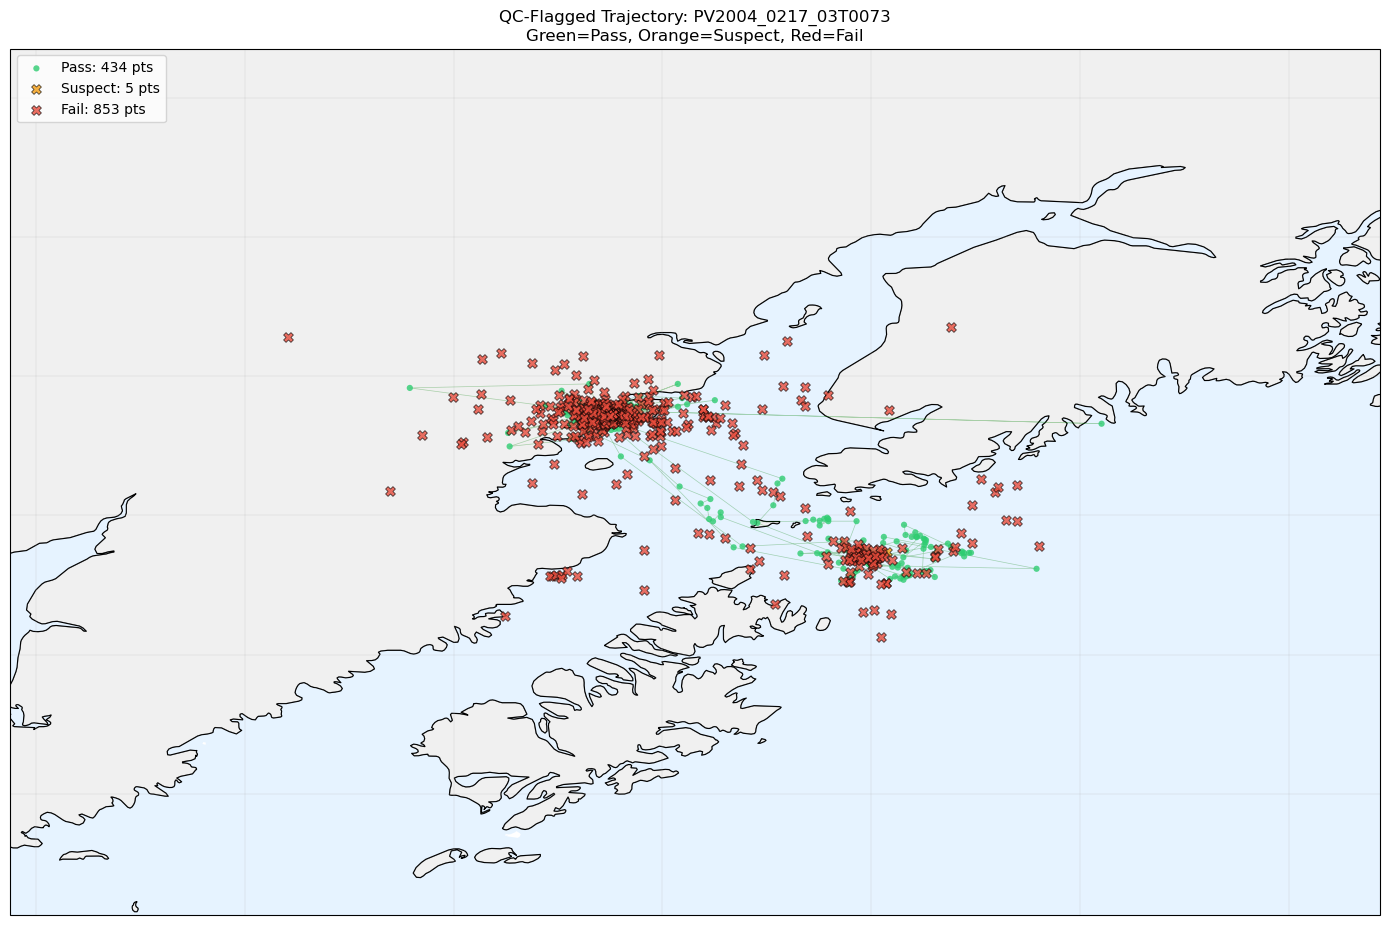

In [27]:
# Create a map showing QC-flagged trajectory
fig, ax = plt.subplots(1, 1, figsize=(14, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Use only valid coordinates for extent calculation
valid_coords = trajectory_df[(trajectory_df[lat_col].between(-90, 90)) & (trajectory_df[lon_col].between(-180, 180))]
lon_min = valid_coords[lon_col].min() - 2
lon_max = valid_coords[lon_col].max() + 2
lat_min = valid_coords[lat_col].min() - 2
lat_max = valid_coords[lat_col].max() + 2

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', edgecolor='gray')
ax.add_feature(cfeature.OCEAN, facecolor='#e6f3ff')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.gridlines(linewidth=0.3, alpha=0.5)

# Define colors for each flag value
flag_colors = {1: '#2ecc71', 2: '#3498db', 3: '#f39c12', 4: '#e74c3c', 9: '#95a5a6'}
flag_labels = {1: 'Pass', 2: 'Not Evaluated', 3: 'Suspect', 4: 'Fail', 9: 'Missing'}

# Plot trajectory line for good points only
good_mask = trajectory_df['qc_aggregate'] == 1
ax.plot(trajectory_df.loc[good_mask, lon_col], trajectory_df.loc[good_mask, lat_col],
        'g-', linewidth=0.5, alpha=0.3, transform=ccrs.PlateCarree())

# Plot points colored by QC flag
for flag_val in sorted(trajectory_df['qc_aggregate'].unique()):
    mask = trajectory_df['qc_aggregate'] == flag_val
    subset = trajectory_df[mask]
    valid_subset = subset[(subset[lat_col].between(-90, 90)) & (subset[lon_col].between(-180, 180))]
    
    if len(valid_subset) > 0:
        ax.scatter(valid_subset[lon_col], valid_subset[lat_col],
                   c=flag_colors.get(flag_val, 'gray'),
                   s=50 if flag_val > 1 else 20,
                   marker='o' if flag_val == 1 else 'X',
                   transform=ccrs.PlateCarree(),
                   label=f"{flag_labels.get(flag_val, f'Unknown')}: {len(subset)} pts",
                   zorder=5 if flag_val > 1 else 4,
                   edgecolors='black' if flag_val > 1 else 'none',
                   linewidths=0.5,
                   alpha=0.8)

# Get deployment ID
deploy_id = trajectory_df['DeployID'].iloc[0] if 'DeployID' in trajectory_df.columns else 'Deployment'

ax.legend(loc='upper left', fontsize=10)
ax.set_title(f"QC-Flagged Trajectory: {deploy_id}\nGreen=Pass, Orange=Suspect, Red=Fail", fontsize=12)
plt.tight_layout()
plt.show()

#### Comparison with ATN Portal

The ATN portal shows all raw (unfiltered) locations when "Locations" is selected in the dropdown. We compare our raw data plot with a screenshot from the portal to verify we're working with the same data and that it is not filtered by any QC in the portal.

/Users/kthyng/miniforge3/envs/atn/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/kthyng/miniforge3/envs/atn/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


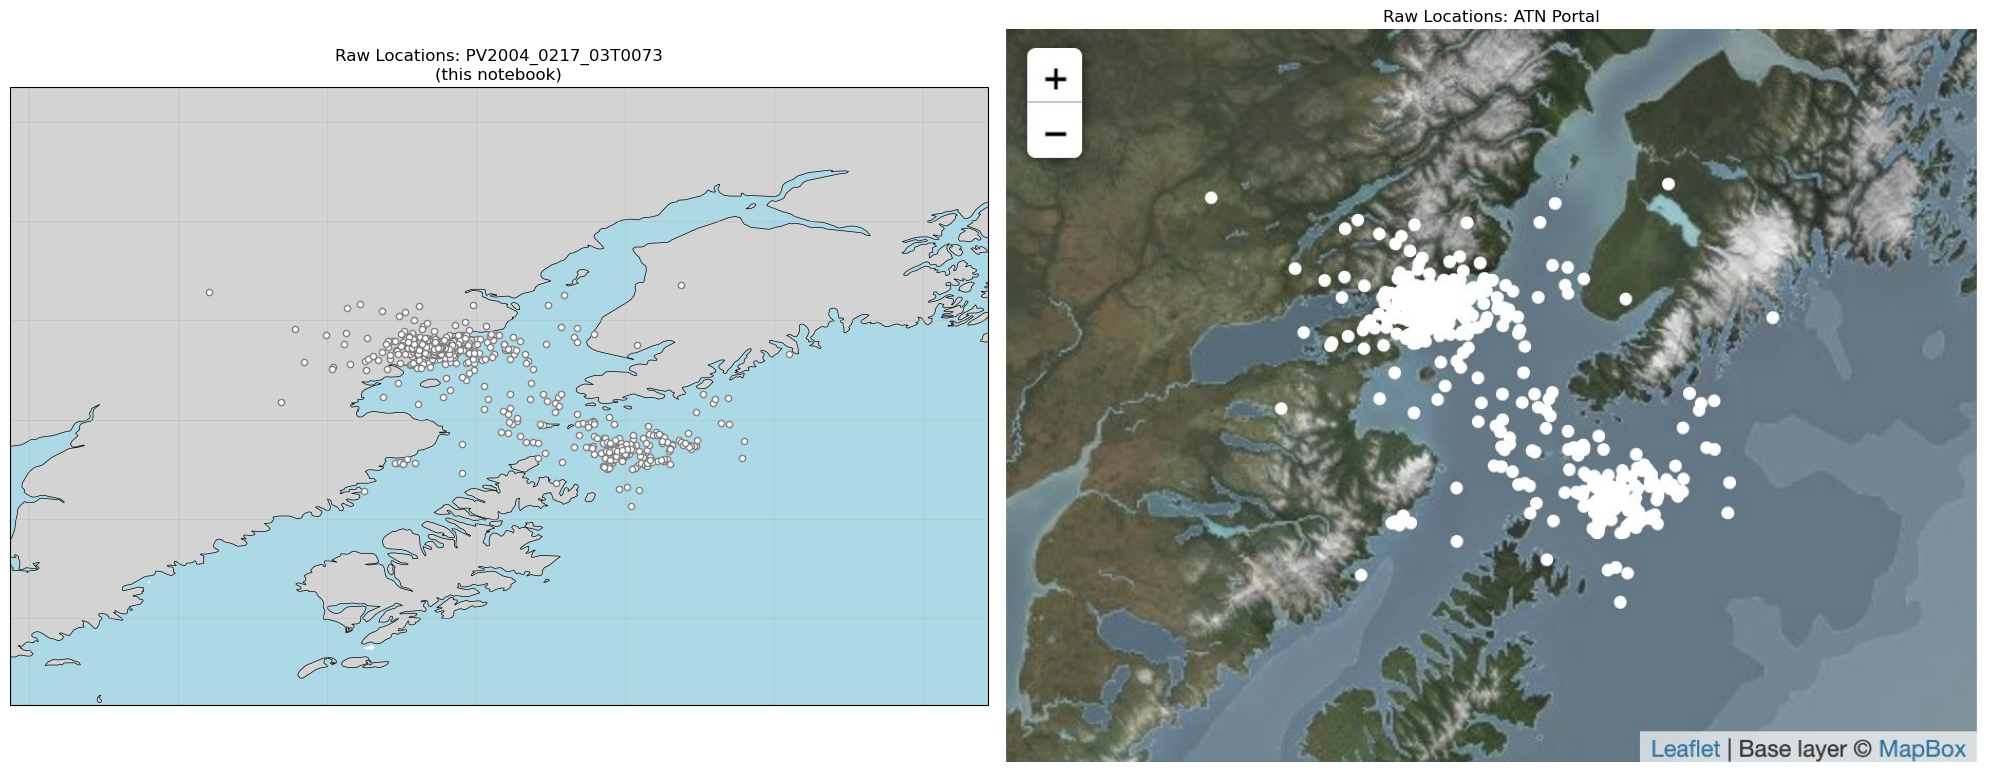

In [29]:
import matplotlib.image as mpimg

portal_img_path = "images/41820_portal_locations.jpg"

fig = plt.figure(figsize=(20, 8))

# Left: raw locations plot
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.LAND, facecolor='lightgray')
ax1.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.gridlines(linewidth=0.5, alpha=0.5)
ax1.scatter(valid_data[lon_col], valid_data[lat_col],
            c='white', edgecolors='gray', s=20,
            transform=ccrs.PlateCarree(), zorder=5)
ax1.set_title(f"Raw Locations: {deploy_id}\n(this notebook)")

# Right: portal screenshot
ax2 = fig.add_subplot(1, 2, 2)
portal_img = mpimg.imread(portal_img_path)
ax2.imshow(portal_img)
ax2.axis('off')
ax2.set_title("Raw Locations: ATN Portal")

plt.tight_layout()
plt.show()

#### Comparison with NCEI Archive

For some projects, the processed version of the data is archived at NCEI. We will compare the quality-controled output from this notebook with the corresponding archive file at NCEI. The following plot and flag count shows that the processing presented in this notebook is the same as what was done to the processed dataset available through NCEI.

In [27]:
# QCed data file
loc = "https://www.ncei.noaa.gov/thredds-ocean/dodsC/ioos/atn/noaa_alaska_fisheries_science_center/atn_41820_harbor-seal_trajectory_20040830-20041229.nc"
ds = xr.open_dataset(loc)
ds

<xarray.Dataset> Size: 497kB
Dimensions:               (obs: 1292)
Coordinates:
    time                  (obs) datetime64[ns] 10kB ...
    z                     (obs) float64 10kB ...
    lat                   (obs) float64 10kB ...
    lon                   (obs) float64 10kB ...
Dimensions without coordinates: obs
Data variables: (12/32)
    deploy_id             object 8B ...
    ptt                   (obs) float64 10kB ...
    instrument            (obs) |S64 83kB ...
    type                  (obs) |S64 83kB ...
    location_class        (obs) |S64 83kB ...
    error_radius          (obs) float64 10kB ...
    ...                    ...
    animal                |S64 64B ...
    instrument_tag        |S64 64B ...
    instrument_location   |S64 64B ...
    taxon_name            |S64 64B ...
    taxon_lsid            |S64 64B ...
    comment               (obs) |S64 83kB ...
Attributes: (12/88)
    date_created:                 2025-11-06T01:41:40Z
    featureType:                  trajectory
    cdm_data_type:                Trajectory
    Conventions:                  CF-1.10, ACDD-1.3, IOOS-1.2, ATN Satellite ...
    argos_program_number:         522
    creator_email:                josh.london@noaa.gov
    ...                           ...
    creator_role:                 principalInvestigator
    creator_sector:               government
    creator_country:              USA
    creator_institution:          NOAA Alaska Fisheries Science Center
    creator_institution_url:      https://www.fisheries.noaa.gov/about/marine...
    citation:                     London, Josh; Boveng, Peter. (2025). Harbor...

/Users/kthyng/miniforge3/envs/atn/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/kthyng/miniforge3/envs/atn/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/kthyng/miniforge3/envs/atn/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/kthyng/miniforge3/envs/atn/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


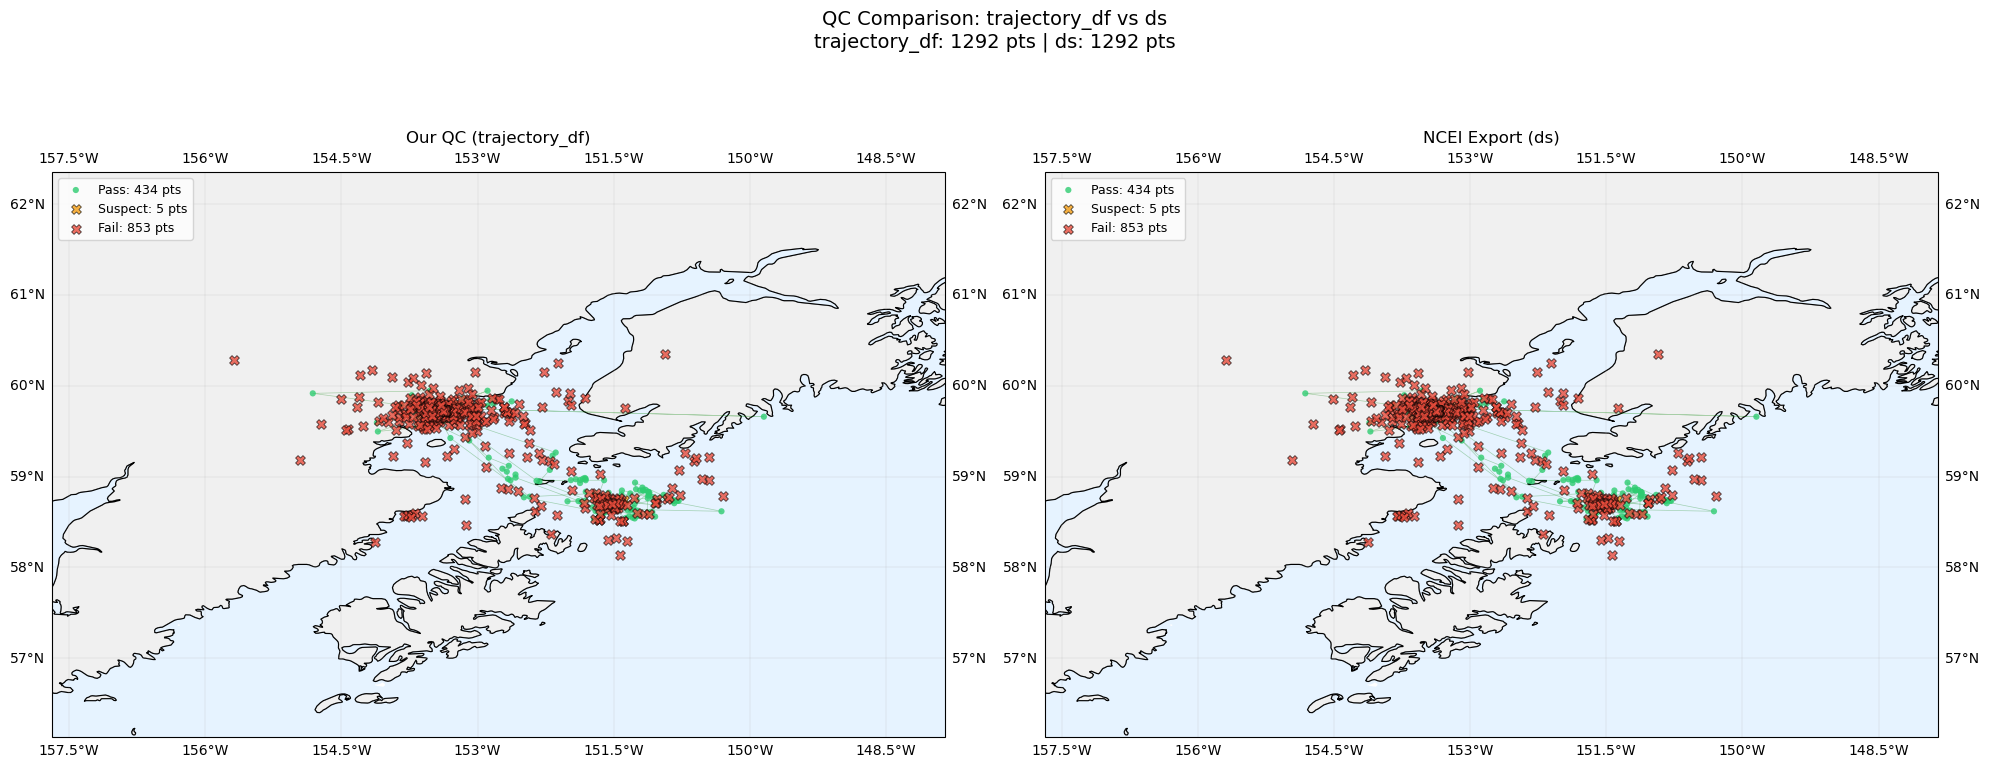

Flag value counts comparison:

Flag         trajectory_df (qc_aggregate)   ds (qartod_rollup_flag)       
------------------------------------------------------------------------
Pass         434                            434                           
Not Evaluated 0                              0                             
Suspect      5                              5                             
Fail         853                            853                           
Missing      0                              0                             


In [28]:
# Compare trajectories and QC flags: our QC (trajectory_df) vs NCEI export (ds)

fig, axes = plt.subplots(1, 2, figsize=(20, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Shared extent from trajectory_df
valid_coords = trajectory_df[(trajectory_df[lat_col].between(-90, 90)) & (trajectory_df[lon_col].between(-180, 180))]
lon_min, lon_max = valid_coords[lon_col].min() - 2, valid_coords[lon_col].max() + 2
lat_min, lat_max = valid_coords[lat_col].min() - 2, valid_coords[lat_col].max() + 2

flag_colors = {1: '#2ecc71', 2: '#3498db', 3: '#f39c12', 4: '#e74c3c', 9: '#95a5a6'}
flag_labels = {1: 'Pass', 2: 'Not Evaluated', 3: 'Suspect', 4: 'Fail', 9: 'Missing'}

# --- Left panel: our QC (trajectory_df) ---
ax = axes[0]
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', edgecolor='gray')
ax.add_feature(cfeature.OCEAN, facecolor='#e6f3ff')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

good_mask = trajectory_df['qc_aggregate'] == 1
ax.plot(trajectory_df.loc[good_mask, lon_col], trajectory_df.loc[good_mask, lat_col],
        'g-', linewidth=0.5, alpha=0.3, transform=ccrs.PlateCarree())

for flag_val in sorted(trajectory_df['qc_aggregate'].unique()):
    mask = trajectory_df['qc_aggregate'] == flag_val
    subset = trajectory_df.loc[mask]
    valid_subset = subset[(subset[lat_col].between(-90, 90)) & (subset[lon_col].between(-180, 180))]
    if len(valid_subset) > 0:
        ax.scatter(valid_subset[lon_col], valid_subset[lat_col],
                   c=flag_colors.get(flag_val, 'gray'),
                   s=50 if flag_val > 1 else 20,
                   marker='o' if flag_val == 1 else 'X',
                   transform=ccrs.PlateCarree(),
                   label=f"{flag_labels.get(flag_val, 'Unknown')}: {len(subset)} pts",
                   zorder=5 if flag_val > 1 else 4,
                   edgecolors='black' if flag_val > 1 else 'none',
                   linewidths=0.5, alpha=0.8)
ax.legend(loc='upper left', fontsize=9)
ax.set_title("Our QC (trajectory_df)", fontsize=12)

# --- Right panel: NCEI export (ds) ---
ax = axes[1]
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', edgecolor='gray')
ax.add_feature(cfeature.OCEAN, facecolor='#e6f3ff')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

rollup = ds['qartod_rollup_flag'].values
ds_lon = ds['lon'].values
ds_lat = ds['lat'].values

good = rollup == 1
ax.plot(ds_lon[good], ds_lat[good],
        'g-', linewidth=0.5, alpha=0.3, transform=ccrs.PlateCarree())

for flag_val in sorted(set(int(v) for v in np.unique(rollup) if not np.isnan(v))):
    mask = rollup == flag_val
    n_pts = mask.sum()
    if n_pts > 0:
        ax.scatter(ds_lon[mask], ds_lat[mask],
                   c=flag_colors.get(flag_val, 'gray'),
                   s=50 if flag_val > 1 else 20,
                   marker='o' if flag_val == 1 else 'X',
                   transform=ccrs.PlateCarree(),
                   label=f"{flag_labels.get(flag_val, 'Unknown')}: {n_pts} pts",
                   zorder=5 if flag_val > 1 else 4,
                   edgecolors='black' if flag_val > 1 else 'none',
                   linewidths=0.5, alpha=0.8)
ax.legend(loc='upper left', fontsize=9)
ax.set_title("NCEI Export (ds)", fontsize=12)
fig.suptitle(f"QC Comparison: trajectory_df vs ds\n"
             f"trajectory_df: {len(trajectory_df)} pts | ds: {len(ds['obs'])} pts",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Flag value comparison ---
print("Flag value counts comparison:")
print(f"\n{'Flag':<12} {'trajectory_df (qc_aggregate)':<30} {'ds (qartod_rollup_flag)':<30}")
print("-" * 72)
for flag_val in [1, 2, 3, 4, 9]:
    n_ours = (trajectory_df['qc_aggregate'] == flag_val).sum()
    n_ncei = int((ds['qartod_rollup_flag'] == flag_val).sum().values)
    print(f"{flag_labels.get(flag_val, 'Unknown'):<12} {n_ours:<30} {n_ncei:<30}")

## BONUS: Modeled Trajectory with aniMotum

The ATN portal visualization for datasets that do not rely on GPE3 tags show a smoothed, modeled trajectory derived from running `aniMotum` (an R state-space model by Ian Jonsen) on the QC'd Argos positions. `aniMotum` corrects for the noise and error inherent in Argos satellite positions by fitting a continuous-time correlated random walk (CRW) model, yielding regularly-spaced predicted locations with uncertainty estimates. The code below will plot an example trajectory of what you see when you click the "animotum" layer in the ATN portal.

Note: not all ATN deployments have sufficient information to be run through `aniMotum`. Please see the Data Flow section on `aniMotum` for more information.

In [43]:
# Start from the raw trajectory_df and filter to QC-passing observations.
# The portal pipeline (packrat/clean_fg_input) removes all rows where the
# aggregate rollup flag == 4 (FAIL), which covers failures from location,
# speed, and time tests. This matches filtering on qc_aggregate != 4 here.
fg_input = trajectory_df[trajectory_df['qc_aggregate'] != 4].copy()

# Rename columns to aniMotum's expected names
fg_input = fg_input.rename(columns={
                            'DeployID': 'id',
                            date_col: 'date',
                            'Quality': 'lc',
                            lon_col: 'lon',
                            lat_col: 'lat',
                            'Error Semi-major axis': 'smaj',
                            'Error Semi-minor axis': 'smin',
                            'Error Ellipse orientation': 'eor',
})

# FastGPS rows get location class 'G'
if 'Type' in fg_input.columns:
    fg_input.loc[fg_input['Type'] == 'FastGPS', 'lc'] = 'G'

# Subset to the 8 columns aniMotum expects (Argos KF format)
fg_input = fg_input[['id', 'date', 'lc', 'lon', 'lat', 'smaj', 'smin', 'eor']].dropna(subset=['date', 'lat', 'lon', 'lc'])

print(f"Input: {len(trajectory_df)} raw points -> {len(fg_input)} after filtering QC failures (qc_aggregate != 4)")

Input: 1292 raw points -> 439 after filtering QC failures (qc_aggregate != 4)


In [44]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

# Install aniMotum into the R library rpy2 is using (if not already installed)
utils = importr('utils')
installed = ro.r('rownames(installed.packages())')
if 'aniMotum' not in list(installed):
    print("Installing aniMotum (this may take several minutes)...")
    utils.install_packages(
        'aniMotum',
        repos=ro.StrVector(['https://cloud.r-project.org', 'https://ianjonsen.r-universe.dev']),
        dependencies=True
    )
    print("Installation complete.")
else:
    print("aniMotum already installed.")

aniMotum = importr('aniMotum')
print("aniMotum loaded successfully.")


aniMotum already installed.
aniMotum loaded successfully.


In [45]:
# aniMotum expects date as a character string in ISO format; convert before passing to R
fg_r_input = fg_input.copy()
fg_r_input['date'] = fg_r_input['date'].dt.strftime('%Y-%m-%d %H:%M:%S')

# Convert pandas DataFrame to R data.frame using localconverter
with localconverter(ro.default_converter + pandas2ri.converter):
    r_fg = ro.conversion.py2rpy(fg_r_input)

print("Input data converted to R data.frame")


Input data converted to R data.frame


In [46]:
print("Fitting aniMotum RW state-space model (this may take a minute)...")

# Fit the SSM — mirrors packrat's foiegras/aniMotum call
fit = aniMotum.fit_ssm(
    r_fg,
    model="rw",
    time_step=2,
    # control=aniMotum.ssm_control(verbose=0),
)

# Extract predicted (regularised) locations
with localconverter(ro.default_converter + pandas2ri.converter):
    predicted = ro.conversion.rpy2py(aniMotum.grab(fit, what='predicted', as_sf=False))

print(f"Model fit complete. Predicted locations: {len(predicted)}")
predicted.head()


Fitting aniMotum RW state-space model (this may take a minute)...
fitting rw SSM to 1 tracks...
 pars:   0.88796 0.90021 -0.95298 0 0 0      pars:   1.0631 1.34898 -1.08181 -0.6173 -0.60846 -0.00697      pars:   1.25561 1.84229 -1.22342 -1.29586 -1.2773 -0.01463      pars:   2.54219 0.55988 -0.97859 -1.83105 -2.13315 0.153      pars:   1.53324 1.56556 -1.17059 -1.41135 -1.46198 0.02155      pars:   1.55918 1.49507 -1.0714 -1.7557 -1.71597 0.10293      pars:   1.66148 1.73039 -0.82202 -1.97803 -1.80966 0.24062      pars:   1.56167 1.47711 -0.53146 -2.0427 -1.93786 0.402      pars:   1.57735 1.61653 -0.25855 -2.03095 -1.95288 0.73467      pars:   1.81841 1.50173 -0.40431 -2.20887 -1.8482 0.99935      pars:   1.61368 1.53985 -0.28811 -2.0739 -1.9833 0.7394      pars:   1.61017 1.58263 -0.33392 -2.12018 -1.9342 0.7881      pars:   1.60405 1.58148 -0.39051 -2.08868 -1.99917 0.83721      pars:   1.62743 1.54433 -0.43158 -2.13486 -1.94349 0.88214      pars:   1.60405 1.58148 -0.39051 -2.08868

,id,date,lon,lat,x,y,x.se,y.se
1,PV2004_0217_03T0073,2004-08-31 00:00:00+00:00,-153.361853,59.740210,-17072.163378,8305.182608,4.115033,4.064547
2,PV2004_0217_03T0073,2004-08-31 02:00:00+00:00,-153.409898,59.749356,-17077.511722,8307.199728,3.259395,2.963721
3,PV2004_0217_03T0073,2004-08-31 04:00:00+00:00,-153.441905,59.729670,-17081.074747,8302.858501,3.400059,3.363232
4,PV2004_0217_03T0073,2004-08-31 06:00:00+00:00,-153.472745,59.711124,-17084.507868,8298.771156,4.331816,4.082498
5,PV2004_0217_03T0073,2004-08-31 08:00:00+00:00,-153.463054,59.706068,-17083.428986,8297.657230,9.514417,9.258957


/Users/kthyng/miniforge3/envs/atn/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/kthyng/miniforge3/envs/atn/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


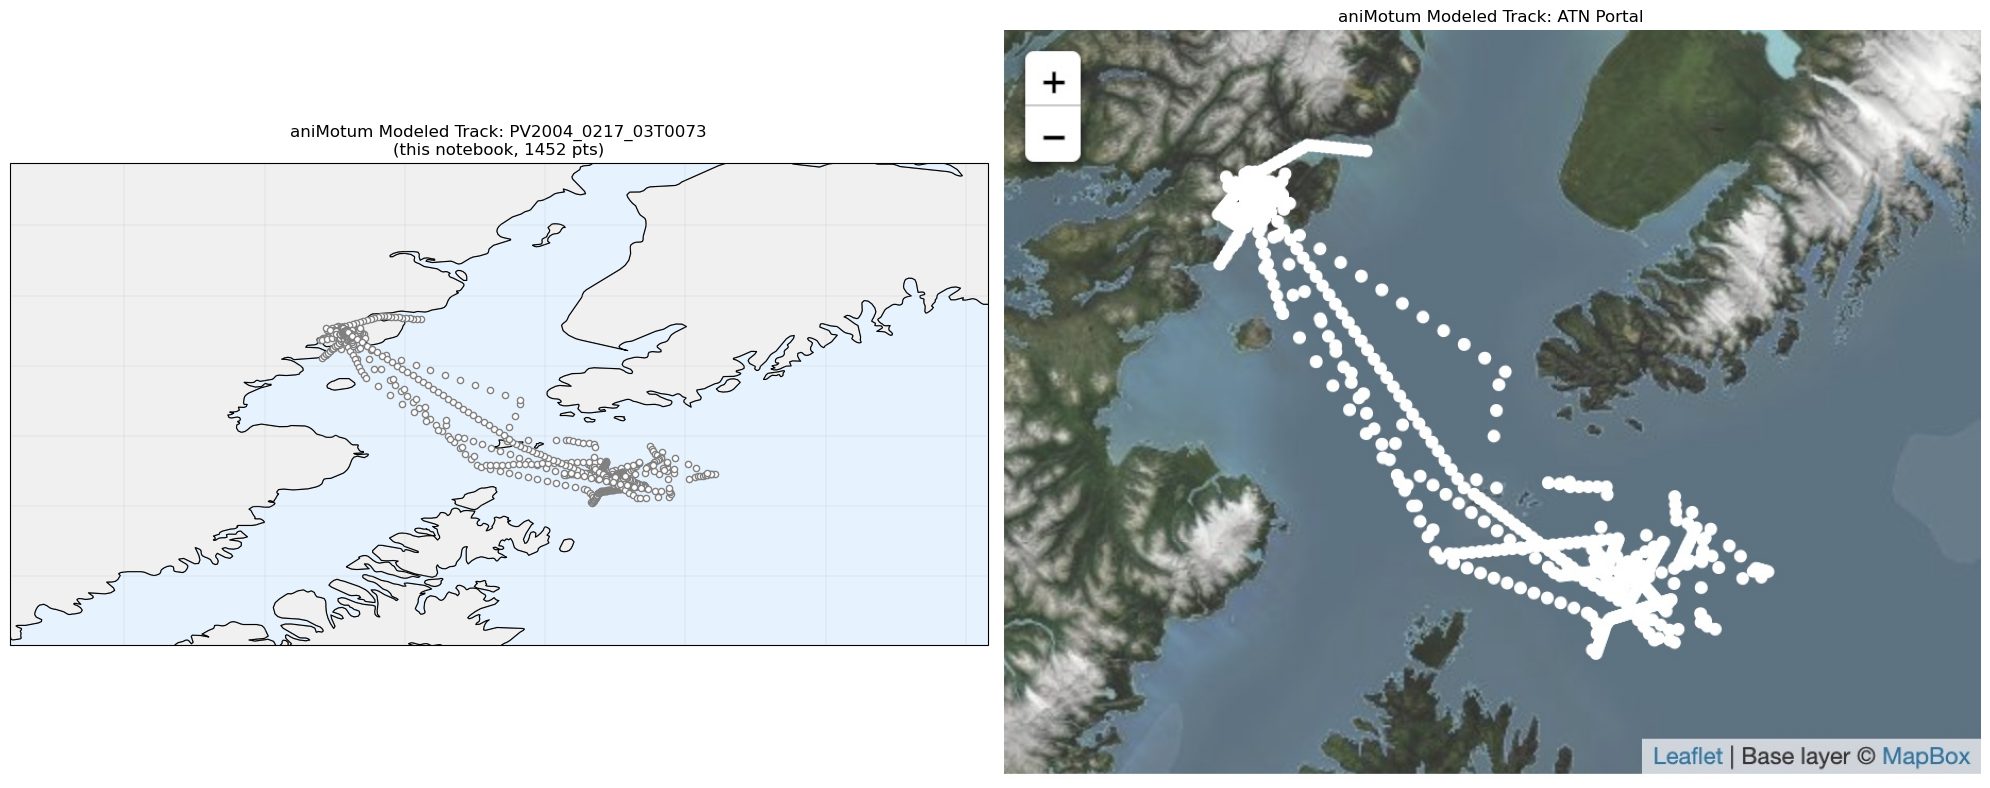

In [62]:
import matplotlib.image as mpimg

portal_img_path = "images/animotum.jpg"

fig = plt.figure(figsize=(20, 8))

# Shared extent from QC'd input data
valid_coords = fg_input[(fg_input['lat'].between(-90, 90)) & (fg_input['lon'].between(-180, 180))]
lon_min, lon_max = valid_coords['lon'].min() - 1, valid_coords['lon'].max() + 1
lat_min, lat_max = valid_coords['lat'].min() - 1, valid_coords['lat'].max() + 1

# --- Left: aniMotum predicted track ---
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.LAND, facecolor='#f0f0f0', edgecolor='gray')
ax1.add_feature(cfeature.OCEAN, facecolor='#e6f3ff')
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.gridlines(linewidth=0.3, alpha=0.5)
ax1.scatter(predicted['lon'], predicted['lat'],
            c='white', edgecolors='gray', s=20,
            transform=ccrs.PlateCarree(), zorder=5)
ax1.set_title(f"aniMotum Modeled Track: {deploy_id}\n(this notebook, {len(predicted)} pts)")

# --- Right: portal screenshot ---
ax2 = fig.add_subplot(1, 2, 2)
portal_img = mpimg.imread(portal_img_path)
ax2.imshow(portal_img)
ax2.axis('off')
ax2.set_title("aniMotum Modeled Track: ATN Portal")

plt.tight_layout()
plt.show()

## ATN DAC Batch QC

The ATN DAC production pipeline runs QC tests using `ioos_qc`'s `PandasStream` and `PandasStore` classes. This approach:
1. Applies all configured tests in a single pass
2. Automatically computes aggregate (rollup) flags
3. Produces standardized output column names

Here's how batch QC works for trajectory data:

In [ ]:
# Batch QC approach for trajectory data using PandasStream

def apply_qc(df, qc_config_yaml, time=None, lon=None, lat=None, z=None):
    """Apply batch QC to a DataFrame using ioos_qc PandasStream.
    
    time, lon, lat, z: column names in df for the respective axes.
    PandasStream uses these to automatically pass tinp/lon/lat to each test.
    """
    config = Config(qc_config_yaml)
    stream = PandasStream(df, time=time, lon=lon, lat=lat, z=z)
    results = stream.run(config)
    
    store_axes = {}
    if time: store_axes['t'] = time
    if lon:  store_axes['x'] = lon
    if lat:  store_axes['y'] = lat
    if z:    store_axes['z'] = z
    
    store = PandasStore(results, axes=store_axes)
    store.compute_aggregate()
    results_df = store.save(write_data=False, write_axes=False)
    
    return pd.concat([df, results_df], axis=1)

# Build QC configuration YAML for trajectory

trajectory_qc_yaml = f"""
{lon_col}:
    qartod:
        location_test:
            bbox: {QC_THRESHOLDS['location_test']['bbox']}
{lat_col}:
    argo:
        speed_test:
            suspect_threshold: {QC_THRESHOLDS['speed_test']['suspect_threshold']}
            fail_threshold: {QC_THRESHOLDS['speed_test']['fail_threshold']}
{date_col}:
    axds:
        valid_range_test:
            valid_span:
                - {QC_THRESHOLDS['valid_range_test']['time']['valid_span'][0]}
                - {QC_THRESHOLDS['valid_range_test']['time']['valid_span'][1]}
"""

print("Trajectory QC Configuration (YAML format):")
print(trajectory_qc_yaml)

# Pass only raw data columns to avoid duplicate QC columns in the result
qc_cols = ['location_test', 'speed_test', 'time_axds_valid_range_test', 'qc_aggregate', 'calculated_speed', 'timestamp']
raw_cols = [c for c in trajectory_df.columns if c not in qc_cols]
trajectory_qc_results = apply_qc(
    trajectory_df[raw_cols],
    trajectory_qc_yaml,
    time=date_col, lon=lon_col, lat=lat_col
)

print("\n" + "="*50)
print("Trajectory QC Results")
print("="*50)

print(f"\nAggregate QC (qartod_rollup) distribution:")
flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
for flag, count in trajectory_qc_results['qartod_rollup'].value_counts().sort_index().items():
    pct = 100 * count / len(trajectory_qc_results)
    print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count:5d} ({pct:.1f}%)")


Trajectory QC Configuration (YAML format):

Longitude:
    qartod:
        location_test:
            bbox: [-180, -90, 180, 90]
Latitude:
    argo:
        speed_test:
            suspect_threshold: 8.0
            fail_threshold: 10.0
Date:
    axds:
        valid_range_test:
            valid_span:
                - 2004-08-30 00:00:00
                - 2004-12-29 23:59:59.999999


Trajectory QC Results

Aggregate QC (qartod_rollup) distribution:
  PASS (1):   434 (33.6%)
  SUSPECT (3):     5 (0.4%)
  FAIL (4):   853 (66.0%)


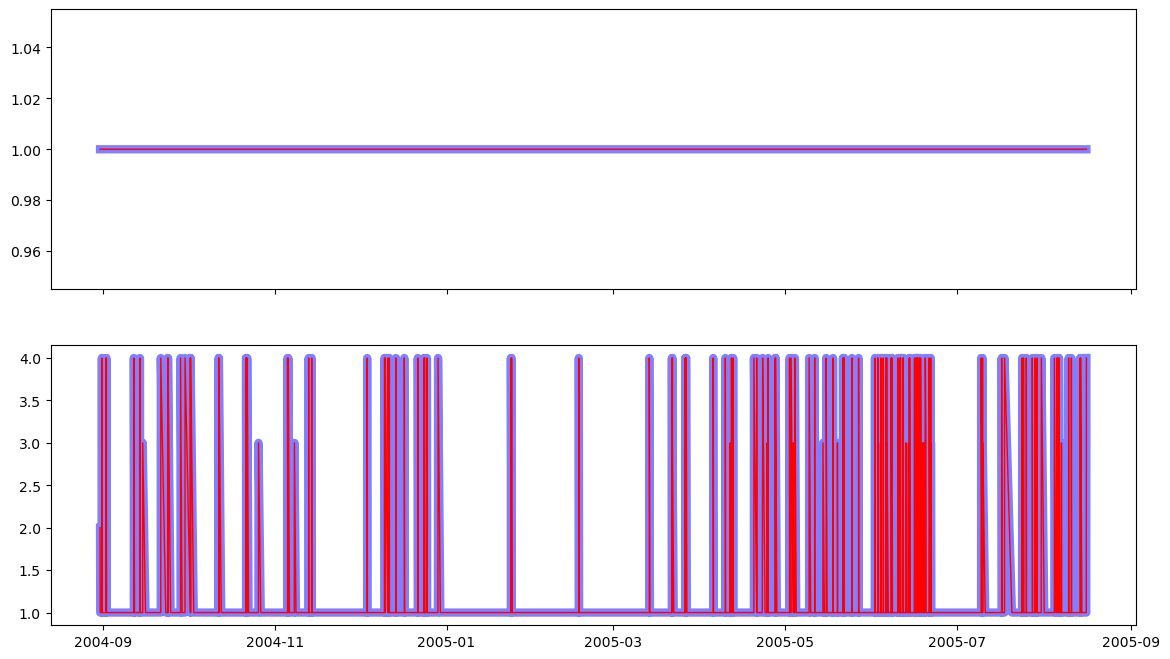

In [58]:
# make sure the QC results match for rollup
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax[0].plot(trajectory_df[date_col], trajectory_df['location_test'], 'b-', alpha=0.5, linewidth=6, label='Speed')
ax[0].plot(trajectory_qc_results[date_col], trajectory_qc_results['Longitude_qartod_location_test'], 'r-', alpha=1, linewidth=1, label='QC Speed')

ax[1].plot(trajectory_df[date_col], trajectory_df['speed_test'], 'b-', alpha=0.5, linewidth=6, label='Speed')
ax[1].plot(trajectory_qc_results[date_col], trajectory_qc_results['Latitude_argo_speed_test'], 'r-', alpha=1, linewidth=1, label='QC Speed')

## References

- [ATN Data Portal](https://portal.atn.ioos.us/)
- [IOOS QARTOD Manual](https://ioos.noaa.gov/project/qartod/)
- [ioos_qc Documentation](https://ioos.github.io/ioos_qc/)
- [Argo Quality Control Manual](https://archimer.ifremer.fr/doc/00228/33951/)
- [Wildlife Computers Data Portal](https://my.wildlifecomputers.com/)
- [ATN Satellite Telemetry Specification](https://ioos.github.io/ioos-atn-data/atn-sat-telem-specification-v1-0.html)